### 過学習が可能であることを確認(最低限学習データは学習できること)

学習画像枚数80枚、Epoch100で学習した。    
汎化性はないものの、学習データに対しては最低限学習できていることを確認できた。  
よって、モデル内の計算やオプティマイザーに問題がある可能性は低い  

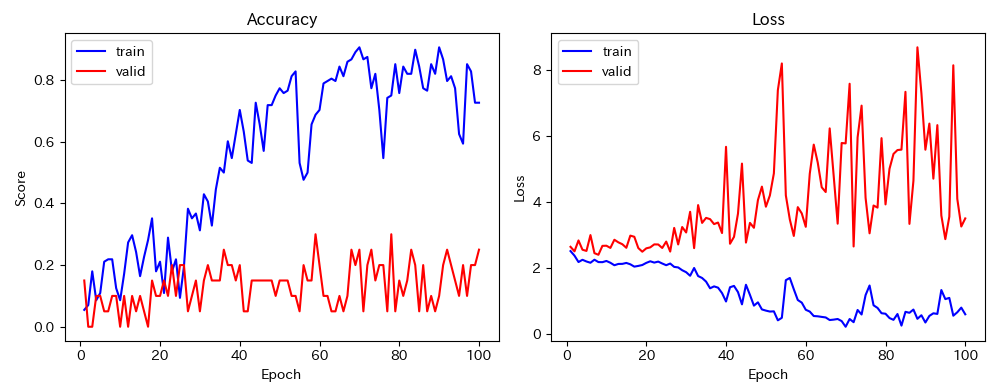
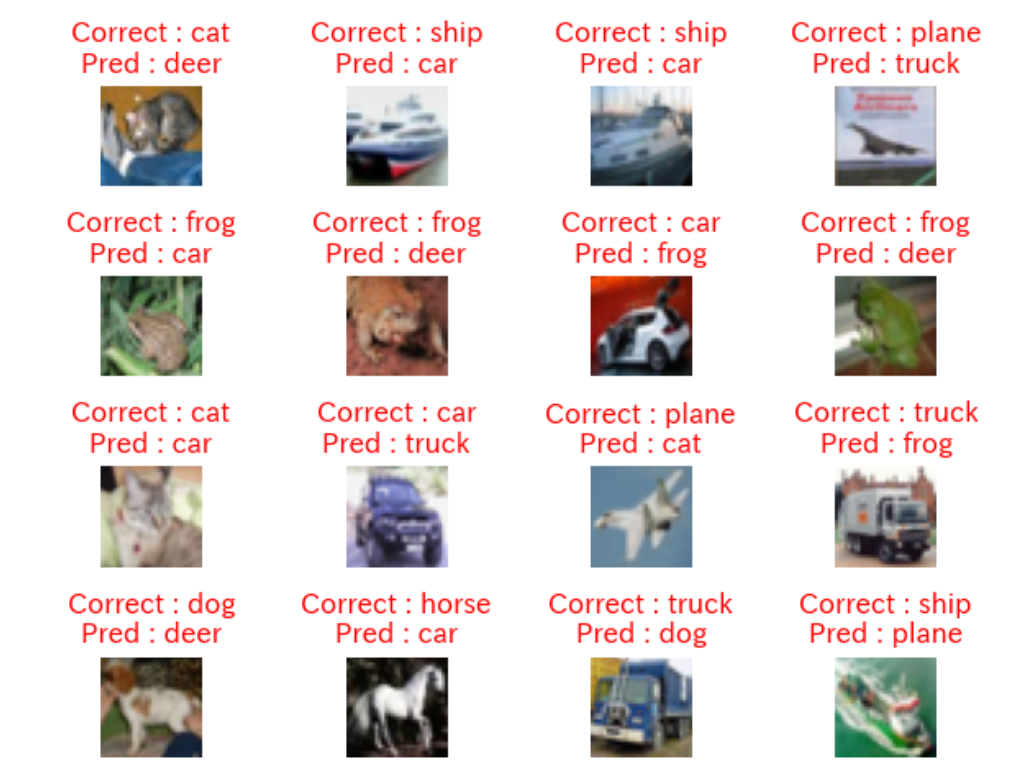

### 汎化性能の問題に焦点を当てる

1. 学習データを100枚→500枚→1000枚→5000枚と増やしたとき、Train/Validation Accuracyがどう変化するか。
2. データ拡張（RandomCrop、RandomHorizontalFlipなど）を使っているか。
3. 学習率が適切か（高すぎても低すぎても汎化しにくくなります）。
4. モデル容量がデータ量に対して大きすぎないか。

### データ数を変えてみる

#### Train images 800, Valid images 200 Max Epoch 10
学習・検証のどちらも正解率、損失が改善している途中で終わっているように見える。  
データ数は変えずにエポックを増やすと汎化性能が上がらないだろうか？  

ただ、800枚学習してAccuracyが23%であるため、精度は低いといえる。  
一先ず、100エポックまで学習して、うまく精度が上がらないようであれば以下の点を調査する。

- 学習率
- モデルの容量(チャネル数、層数)は十分か
- 重み初期化に問題はないか
- Optimizerの計算


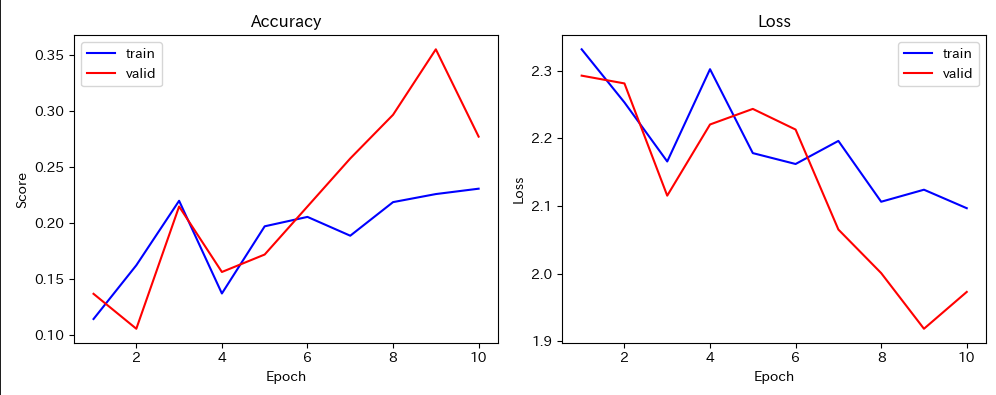

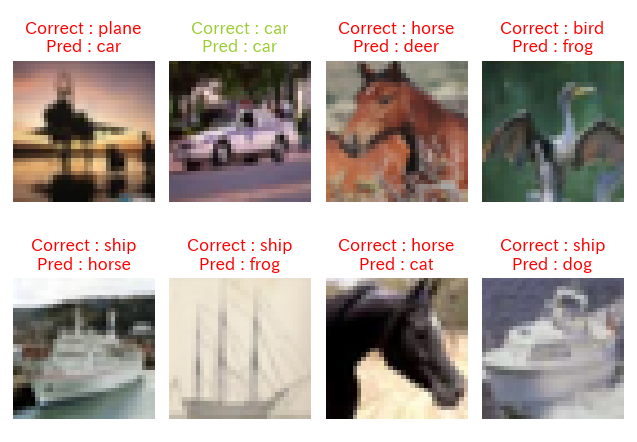

#### Train images 800, Valid images 200 Max Epoch 100

20エポックあたりからAccuracy, Lossともに学習データと検証データで結果が大きく乖離している。  
つまり、過学習が起きていると考えられる。  
また、検証データについてはAccuracyは上がったものの、Lossは下がっていることから、正解する確率は上がったが、モデルが予測に過剰に自信を持つようになったためLossは大きくなっている
- 学習データと検証データに存在するラベルの分布に違いがある？学習データにはCarのデータが多いが検証データにはshipが多いとか。
>CIFAR-10を通常の方法（ランダムシャッフル後にtrain/validへ分割）で分割しているなら、この可能性は低い



##### 学習データ
Accuracy : 10% → 80%
loss     : 2.3 → 0.5

##### 検証データ
Accuracy : 10% → 30%
loss     : 2.3 → 3

Testデータに対する評価 : Accuracy : 23.44%, Loss : 3.3696722984313965

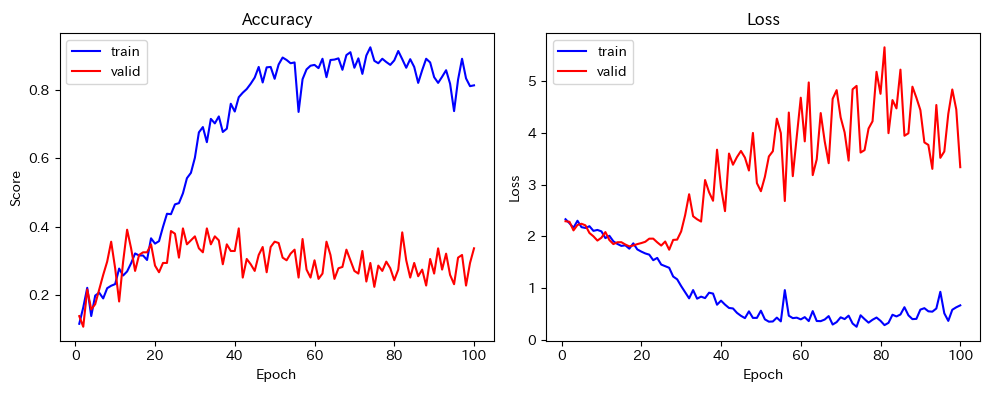
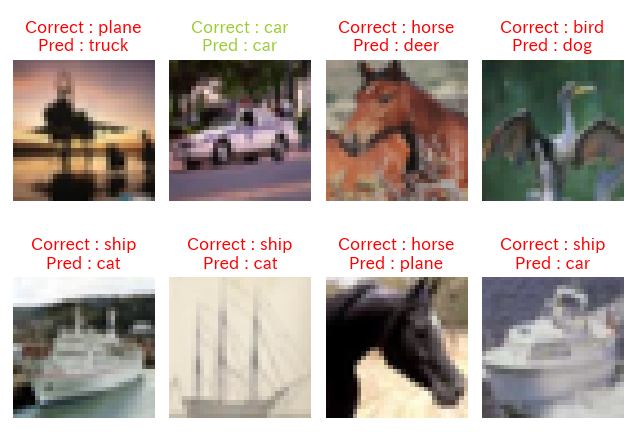

### 使用しているデータを観察する

1. クラスごとの正解率を確認する(学習・検証)  
→どのクラスが得意でどのクラスが苦手か分析  
2. 混同行列を見る(学習・検証)  
→正解に対する予測を可視化できるため、似たクラスを分類できていないかどうかや、完全にランダムかどうかを調べることができる  
3. 学習データと検証データのラベルの分布を可視化する(学習・検証)  
→学習しているデータに偏りがあることで特定のラベルにのみ、分類が得意になっていないか調査  